# SI'26 – Week 1: Urdu OCR Dataset Collection
**Author: Qandeel Asim**

---

## What This Notebook Does

This notebook builds a labeled image–text dataset for training and evaluating **Urdu OCR (Optical Character Recognition)** models.  
It collects data from **four sources**, applies **data augmentation**, validates the dataset, creates a **train/test split**, and generates **statistics & visualizations**.

### Data Sources Used

| # | Source | Type | How Obtained | License |
|---|--------|------|--------------|---------|
| 1 | **UTRSet-Real** | Real printed Urdu text | Downloaded from Google Drive (UTRNet paper, ICDAR 2023) | CC BY-NC-SA 4.0 |
| 2 | **Synthetic (Noto Nastaliq)** | Generated images | Rendered in-notebook using Pillow + Noto Nastaliq Urdu font | Free (Google Fonts OFL) |
| 3 | **Augmented Variants** | Generated from Source 2 | Blur / noise / rotation applied to synthetic images | Same as Source 2 |
| 4 | **Manual Screenshots** | Real-world Urdu text | Taken manually from Dawn Urdu, BBC Urdu, Jang, Wikipedia | Research use only |

### Other Public Urdu OCR Datasets (for reference / future use)

| Dataset | Description | Link |
|---------|-------------|------|
| **UTRSet-Real** | 2,000+ cropped word images from printed Urdu documents | [Google Drive (via UTRNet)](https://drive.google.com/file/d/1mABkzaWe1hLikXCaM5nmLsBCWtxvDE7T) |
| **UTRSet-Synthetic** | Synthetically generated printed Urdu word images | Same UTRNet release |
| **UPTI (Urdu Printed Text Images)** | Large-scale printed Urdu dataset, line-level | [GitHub - UrduOCR](https://github.com/sysopfb/UrduOCR) |
| **OHFCR (Offline Handwritten Farsi/Urdu)** | Handwritten character recognition dataset | Search IEEE Dataport |
| **HuggingFace: `Kamran92/urdu-news`** | Urdu news text corpus (for sentence generation) | [HuggingFace Hub](https://huggingface.co/datasets/Kamran92/urdu-news) |
| **CRULP Urdu NLP Resources** | Various Urdu text corpora (CRULP, NUCES) | [crulp.org](http://www.crulp.org) |

All images are saved to `data/raw/<category>/` and labeled in `data/labels.csv` (`image`, `text`, `source`, `split` columns).


## 0. Setup — Install & Import

In [1]:
# Install all required libraries
!pip install Pillow arabic-reshaper python-bidi gdown matplotlib -q
print("All dependencies installed.")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.2/296.2 kB 3.7 MB/s eta 0:00:00
All dependencies installed.


In [2]:
# Standard library imports
import csv
import json
import os
import random
import shutil
import subprocess
import urllib.request
import zipfile
from pathlib import Path

# Image processing
from PIL import Image, ImageDraw, ImageFilter, ImageFont, ImageEnhance

# Urdu text rendering
import arabic_reshaper
from bidi.algorithm import get_display

# Visualization
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Fix random seed so augmentation results are reproducible
random.seed(42)
print("Imports complete.")


Imports complete.


In [3]:
import gdown
import zipfile
import os

# Google Drive file ID of UTRSet-Real
FILE_ID = "1mABkzaWe1hLikXCaM5nmLsBCWtxvDE7T"
ZIP_PATH = "utrset_real_download/utrset_real.zip"

# Create the directory if it doesn't exist
os.makedirs(os.path.dirname(ZIP_PATH), exist_ok=True)

# Download
print("Downloading UTRSet-Real... (may take 2-3 minutes)")
gdown.download(id=FILE_ID, output=ZIP_PATH, quiet=False)

# Extract
print("Extracting...")
with zipfile.ZipFile(ZIP_PATH, "r") as zf:
    zf.extractall("utrset_real_download/extracted")

print("Done! Files extracted.")
print(os.listdir("utrset_real_download/extracted"))

Downloading...
From (original): https://drive.google.com/uc?id=1mABkzaWe1hLikXCaM5nmLsBCWtxvDE7T
From (redirected): https://drive.google.com/uc?id=1mABkzaWe1hLikXCaM5nmLsBCWtxvDE7T&confirm=t&uuid=8a8564d7-49e3-4b2e-b8fa-0ba43ec15056
To: /content/utrset_real_download/utrset_real.zip
100%|██████████| 212M/212M [00:03<00:00, 55.8MB/s]


Extracting...
Done! Files extracted.
['__MACOSX', 'UTRSet-Real']


## 1. Folder Structure

We create one folder per image category. This makes it easy to track where each image came from.

In [4]:
# Category folders — add more if needed
FOLDERS = [
    'data/raw/newspaper',
    'data/raw/books',
    'data/raw/signboards',
    'data/raw/synthetic',
    'data/raw/augmented',
    'data/raw/other',
]

LABELS_CSV   = 'data/labels.csv'       # master label file
TRAIN_CSV    = 'data/train.csv'        # 80% split
TEST_CSV     = 'data/test.csv'         # 20% split

for folder in FOLDERS:
    os.makedirs(folder, exist_ok=True)
    print(f"  Created: {folder}")

print("\nFolder structure ready!")


  Created: data/raw/newspaper
  Created: data/raw/books
  Created: data/raw/signboards
  Created: data/raw/synthetic
  Created: data/raw/augmented
  Created: data/raw/other

Folder structure ready!


In [5]:
import shutil
shutil.make_archive('my_dataset', 'zip', 'data')
print("ZIP ready!")

ZIP ready!


## 2. Helper Functions

### 2a. labels.csv writer
This function merges new rows with existing records so the notebook can be re-run without duplicating or overwriting any entries.  
The CSV now has four columns: `image`, `text`, `source`, `split`.

In [6]:
def append_to_labels_csv(new_rows, labels_csv=LABELS_CSV):
    """
    Append new_rows to labels_csv, preserving any rows already present.
    Each row must be a dict with keys: image, text, source, split.
    """
    existing_rows = []
    if os.path.exists(labels_csv):
        with open(labels_csv, 'r', encoding='utf-8') as f:
            existing_rows = list(csv.DictReader(f))

    all_rows = existing_rows + new_rows

    os.makedirs(os.path.dirname(labels_csv), exist_ok=True)
    with open(labels_csv, 'w', newline='', encoding='utf-8') as f:
        writer = csv.DictWriter(f, fieldnames=['image', 'text', 'source', 'split'])
        writer.writeheader()
        writer.writerows(all_rows)

    print(f"  labels.csv: {len(all_rows)} total entries (+{len(new_rows)} new).")
    return all_rows


### 2b. Image quality validator

In [7]:
def is_valid_image(path):
    """
    Returns True only if the file:
      - exists on disk
      - can be opened by Pillow without error
      - is not a completely blank (all-white or all-black) image
    """
    if not os.path.exists(path):
        return False
    try:
        img = Image.open(path).convert('L')   # convert to grayscale
        pixels = list(img.getdata())
        unique = set(pixels)
        if len(unique) <= 2:                   # blank image — only 1 or 2 pixel values
            return False
        return True
    except Exception:
        return False


## 3. Source 1 — UTRSet-Real (Public Research Dataset)

**UTRSet-Real** is a printed Urdu text dataset released as part of the UTRNet research paper (ICDAR 2023).  
The notebook downloads the dataset as a ZIP from Google Drive, extracts it, finds the `gt.txt` ground-truth file, and copies `N_SAMPLES` image–text pairs into `data/raw/other/`.

> **Citation:** Rahman, A., Ghosh, A., & Arora, C. (2023). *UTRNet: High-Resolution Urdu Text Recognition in Printed Documents.* ICDAR 2023, Springer Nature Switzerland.  
> **License:** CC BY-NC-SA 4.0 — non-commercial, research use only.


In [8]:
# ── Configuration ──────────────────────────────────────────────────────────
GDRIVE_FILE_ID = "1mABkzaWe1hLikXCaM5nmLsBCWtxvDE7T"
DOWNLOAD_DIR   = "utrset_real_download"
ZIP_PATH       = os.path.join(DOWNLOAD_DIR, "utrset_real.zip")
EXTRACT_DIR    = os.path.join(DOWNLOAD_DIR, "extracted")
UTRSET_OUT_DIR = "data/raw/other"
N_SAMPLES      = 60   # number of UTRSet-Real samples to include


In [9]:
def download_utrset():
    """Download UTRSet-Real ZIP from Google Drive (skips if already downloaded)."""
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    if os.path.exists(ZIP_PATH):
        print(f"Already downloaded: {ZIP_PATH}")
        return

    print("Downloading UTRSet-Real from Google Drive (may take a few minutes)...")
    try:
        import gdown
        gdown.download(id=GDRIVE_FILE_ID, output=ZIP_PATH, quiet=False)
    except ImportError:
        subprocess.run(["gdown", "--id", GDRIVE_FILE_ID, "-O", ZIP_PATH], check=True)

    # Google Drive sometimes returns an HTML warning page instead of the real file
    if not os.path.exists(ZIP_PATH) or os.path.getsize(ZIP_PATH) < 1024:
        raise RuntimeError(
            "Download failed or returned an HTML warning page.\n"
            "Open the link manually in your browser and download it:\n"
            f"  https://drive.google.com/file/d/{GDRIVE_FILE_ID}/view"
        )


def extract_utrset():
    """Extract the downloaded ZIP (skips if already extracted)."""
    if os.path.exists(EXTRACT_DIR) and os.listdir(EXTRACT_DIR):
        print(f"Already extracted: {EXTRACT_DIR}")
        return
    os.makedirs(EXTRACT_DIR, exist_ok=True)
    print("Extracting ZIP...")
    with zipfile.ZipFile(ZIP_PATH, "r") as zf:
        zf.extractall(EXTRACT_DIR)
    print("Extraction complete.")


def find_gt_file(root):
    """Walk the extracted folder tree and return any ground-truth text files found."""
    candidates = []
    for dirpath, _, filenames in os.walk(root):
        for fname in filenames:
            if fname.lower() in ("gt.txt", "ground_truth.txt", "labels.txt"):
                candidates.append(os.path.join(dirpath, fname))
    return candidates


def find_images(root):
    """Return all PNG/JPG/JPEG paths under root."""
    images = []
    for dirpath, _, filenames in os.walk(root):
        for fname in filenames:
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                images.append(os.path.join(dirpath, fname))
    return images


In [10]:
def collect_utrset_samples():
    """
    Full pipeline: download → extract → parse gt.txt → copy N_SAMPLES pairs.
    Returns a list of row dicts for labels.csv.
    """
    download_utrset()
    extract_utrset()

    gt_files = find_gt_file(EXTRACT_DIR)
    images   = find_images(EXTRACT_DIR)
    print(f"Found {len(gt_files)} ground-truth file(s), {len(images)} image(s) in archive.")

    os.makedirs(UTRSET_OUT_DIR, exist_ok=True)
    new_rows = []

    if not gt_files:
        print("No ground-truth file found — skipping UTRSet-Real.")
        return new_rows

    gt_path = gt_files[0]
    print(f"Parsing ground truth: {gt_path}")
    with open(gt_path, "r", encoding="utf-8") as f:
        lines = [l.strip() for l in f if l.strip()]

    gt_dir = os.path.dirname(gt_path)
    for line in lines:
        if len(new_rows) >= N_SAMPLES:
            break

        # gt.txt format: "<img_relative_path>\t<text>" or "<img_relative_path> <text>"
        if "\t" in line:
            img_rel, text = line.split("\t", 1)
        elif " " in line:
            img_rel, text = line.split(" ", 1)
        else:
            continue

        src = os.path.join(gt_dir, img_rel)
        if not os.path.exists(src):
            continue

        ext      = os.path.splitext(src)[1]
        dst_name = f"utrset_{len(new_rows)+1:03d}{ext}"
        dst      = os.path.join(UTRSET_OUT_DIR, dst_name)
        shutil.copy2(src, dst)

        if is_valid_image(dst):
            new_rows.append({
                'image': dst, 'text': text.strip(),
                'source': 'utrset_real', 'split': ''
            })

    print(f"Copied {len(new_rows)} valid UTRSet-Real samples → {UTRSET_OUT_DIR}")
    return new_rows


In [11]:
utrset_rows = collect_utrset_samples()
append_to_labels_csv(utrset_rows)


Already downloaded: utrset_real_download/utrset_real.zip
Already extracted: utrset_real_download/extracted
Found 2 ground-truth file(s), 22322 image(s) in archive.
Parsing ground truth: utrset_real_download/extracted/UTRSet-Real/test/gt.txt
Copied 60 valid UTRSet-Real samples → data/raw/other
  labels.csv: 60 total entries (+60 new).


[{'image': 'data/raw/other/utrset_001.jpg',
  'text': 'مل سکتا ہے،’’',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_002.jpg',
  'text': 'لفظوں کی یہی عظمت اور ان کی بہی شاہانہ مقام ہے جسے',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_003.jpg',
  'text': 'پہچان کر عہد الزبتھ کے ڈراما نگاروں اور خصوساً شیکسپیر نے ڈرامے',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_004.jpg',
  'text': 'کو ادبی عظمت بھی دی اور اس کی ادبی حیثیت میں وہ شاہانہ شکوہ',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_005.jpg',
  'text': 'بھی  پیدا کیا جس کی طرف ایس اور برنارڈشا نے اشارتاً اور یٹس',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_006.jpg',
  'text': 'نے واضح لفظوںمیں شادہ کیا ہے۔ عہد الزنتھ کے',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_007.jpg',
  'text': 'ڈراما نگاروں نے ڈرامے کی فنی اہمیت کو پوری طرح محسوس

## 4. Source 2 — Synthetic Urdu Images

Urdu sentences are rendered into images using the **Noto Nastaliq Urdu** font.  
`arabic_reshaper` joins letters into their correct connected forms; `python-bidi` handles right-to-left direction.

We use **three visual styles** (white background, cream background, light noise background) to add variety.


In [12]:
# ── 50 Urdu sentences covering different topics ──────────────────────────
URDU_TEXTS = [
    # Everyday / motivational
    "پاکستان زندہ باد",
    "محنت کامیابی کی کنجی ہے",
    "علم انسان کو روشنی دیتا ہے",
    "وقت کی قدر کرنی چاہیے",
    "صحت سب سے بڑی نعمت ہے",
    "دوستی ایک قیمتی رشتہ ہے",
    "محنت کبھی رائیگاں نہیں جاتی",
    "ہمت مرداں مدد خدا",
    "اتحاد میں برکت ہے",
    "سچائی بہترین پالیسی ہے",
    # Geography / general knowledge
    "کراچی پاکستان کا سب سے بڑا شہر ہے",
    "لاہور پاکستان کا دل ہے",
    "اسلام آباد پاکستان کا دارالحکومت ہے",
    "دریائے سندھ پاکستان کا سب سے بڑا دریا ہے",
    "کے ٹو دنیا کی دوسری بلند ترین چوٹی ہے",
    # Education / science
    "تعلیم ہر انسان کا حق ہے",
    "سائنس نے دنیا کو بدل دیا ہے",
    "ریاضی ایک مشکل لیکن دلچسپ مضمون ہے",
    "آرٹیفیشل انٹیلیجنس مستقبل کی ٹیکنالوجی ہے",
    "کمپیوٹر نے انسانی زندگی آسان کر دی ہے",
    # News / current affairs style
    "حکومت نے نئی تعلیمی پالیسی کا اعلان کیا",
    "پاکستان اور چین کے درمیان تجارت بڑھ رہی ہے",
    "ملک میں بارشوں کا نیا سلسلہ شروع ہو گیا",
    "اسٹاک مارکیٹ میں آج تیزی کا رجحان رہا",
    "نئے منصوبے کی بنیاد رکھ دی گئی",
    # Poetry / literature
    "شعر و ادب کا سفر جاری ہے",
    "اردو ادب کی تاریخ بہت پرانی ہے",
    "غالب اردو شاعری کے عظیم شاعر تھے",
    "اقبال کا کلام آج بھی متعلق ہے",
    "فیض احمد فیض نے انقلابی شاعری کی",
    # Health / food
    "آج کا موسم خوشگوار ہے",
    "پھل اور سبزیاں صحت کے لیے ضروری ہیں",
    "صاف پانی پینا صحت کے لیے اہم ہے",
    "ورزش کو روزانہ کا معمول بنائیں",
    "متوازن غذا لمبی عمر کی ضمانت ہے",
    # Technology
    "موبائل فون نے دنیا کو ایک گاؤں بنا دیا",
    "انٹرنیٹ نے معلومات تک رسائی آسان کی",
    "الیکٹرک گاڑیاں مستقبل کی سواری ہیں",
    "سولر انرجی ماحول دوست توانائی ہے",
    "ڈیجیٹل ادائیگی تیزی سے مقبول ہو رہی ہے",
    # Religion / culture
    "رمضان مسلمانوں کا مقدس مہینہ ہے",
    "عید الفطر خوشیوں کا تہوار ہے",
    "قرآن مجید مسلمانوں کی مقدس کتاب ہے",
    "پاکستان کا قیام چودہ اگست انیس سو سینتالیس کو ہوا",
    "بسم اللہ الرحمٰن الرحیم",
    # Short phrases / signboard style
    "داخلہ ممنوع",
    "خطرہ ہائی وولٹیج",
    "آگے سڑک بند ہے",
    "یہاں پارکنگ منع ہے",
    "براہ کرم خاموش رہیں",
    "شکریہ",
]

print(f"Total Urdu sentences: {len(URDU_TEXTS)}")


Total Urdu sentences: 51


In [13]:
# Download Noto Nastaliq Urdu font from Google Fonts repo
FONT_PATH = "NotoNastaliqUrdu-Regular.ttf"

if not os.path.exists(FONT_PATH):
    font_url = (
        "https://raw.githubusercontent.com/google/fonts/main/ofl/"
        "notonastaliqurdu/NotoNastaliqUrdu%5Bwght%5D.ttf"
    )
    try:
        urllib.request.urlretrieve(font_url, FONT_PATH)
        print(f"Font downloaded: {FONT_PATH}")
    except Exception as e:
        print(f"Auto-download failed ({e}).")
        print("Manually download 'Noto Nastaliq Urdu' from fonts.google.com")
        print(f"and upload it to your Colab file panel as: {FONT_PATH}")

font_small  = ImageFont.truetype(FONT_PATH, 28)   # small text — signboard style
font_medium = ImageFont.truetype(FONT_PATH, 36)   # default
font_large  = ImageFont.truetype(FONT_PATH, 48)   # large — book/newspaper headline
print("Fonts loaded.")


Font downloaded: NotoNastaliqUrdu-Regular.ttf
Fonts loaded.


In [14]:
# Visual style configurations for synthetic images
# Each style dict defines: background color, text color, font size, padding
STYLES = [
    {"bg": (255, 255, 255), "fg": (0,   0,   0),   "font": "medium", "pad": 20},  # white
    {"bg": (255, 251, 230), "fg": (30,  30,  30),  "font": "medium", "pad": 24},  # cream
    {"bg": (240, 240, 240), "fg": (10,  10,  80),  "font": "large",  "pad": 30},  # light gray, blue text
    {"bg": (255, 255, 255), "fg": (0,   0,   0),   "font": "small",  "pad": 14},  # white, small (signboard)
]

FONT_MAP = {
    "small":  font_small,
    "medium": font_medium,
    "large":  font_large,
}


def render_urdu_image(text, style):
    """
    Render a single Urdu text string into a PIL Image using the given style dict.
    Returns the PIL Image object.
    """
    font_obj   = FONT_MAP[style["font"]]
    pad        = style["pad"]
    bg_color   = style["bg"]
    text_color = style["fg"]

    # Reshape Urdu characters and apply RTL direction
    reshaped  = arabic_reshaper.reshape(text)
    bidi_text = get_display(reshaped)

    # Measure text size on a throwaway canvas
    dummy = ImageDraw.Draw(Image.new("RGB", (10, 10)))
    bbox  = dummy.textbbox((0, 0), bidi_text, font=font_obj)
    w     = bbox[2] - bbox[0]
    h     = bbox[3] - bbox[1]

    # Create actual image with padding
    img  = Image.new("RGB", (w + pad * 2, h + pad * 2), color=bg_color)
    draw = ImageDraw.Draw(img)
    draw.text((pad - bbox[0], pad - bbox[1]), bidi_text, fill=text_color, font=font_obj)
    return img


In [15]:
def generate_synthetic_images():
    """
    Render all URDU_TEXTS in all STYLES and save to data/raw/synthetic/.
    Returns a list of label row dicts.
    """
    rows  = []
    count = 0

    for i, text in enumerate(URDU_TEXTS):
        # Cycle through styles so each sentence gets a different look
        style     = STYLES[i % len(STYLES)]
        img       = render_urdu_image(text, style)
        save_path = f"data/raw/synthetic/urdu_{i+1:03d}.png"
        img.save(save_path)
        rows.append({
            'image': save_path, 'text': text,
            'source': 'synthetic', 'split': ''
        })
        count += 1

    print(f"Generated {count} synthetic images → data/raw/synthetic/")
    return rows

synthetic_rows = generate_synthetic_images()
append_to_labels_csv(synthetic_rows)


Generated 51 synthetic images → data/raw/synthetic/
  labels.csv: 111 total entries (+51 new).


[{'image': 'data/raw/other/utrset_001.jpg',
  'text': 'مل سکتا ہے،’’',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_002.jpg',
  'text': 'لفظوں کی یہی عظمت اور ان کی بہی شاہانہ مقام ہے جسے',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_003.jpg',
  'text': 'پہچان کر عہد الزبتھ کے ڈراما نگاروں اور خصوساً شیکسپیر نے ڈرامے',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_004.jpg',
  'text': 'کو ادبی عظمت بھی دی اور اس کی ادبی حیثیت میں وہ شاہانہ شکوہ',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_005.jpg',
  'text': 'بھی  پیدا کیا جس کی طرف ایس اور برنارڈشا نے اشارتاً اور یٹس',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_006.jpg',
  'text': 'نے واضح لفظوںمیں شادہ کیا ہے۔ عہد الزنتھ کے',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_007.jpg',
  'text': 'ڈراما نگاروں نے ڈرامے کی فنی اہمیت کو پوری طرح محسوس

## 5. Source 3 — Data Augmentation

Augmentation artificially increases dataset size and makes models more robust by creating
slightly distorted versions of the synthetic images.

We apply three augmentation types:
| Type | Effect |
|------|--------|
| **Gaussian Blur** | Simulates out-of-focus or low-resolution scans |
| **Brightness jitter** | Simulates different lighting conditions |
| **Slight rotation** | Simulates tilted documents or camera angle |


In [16]:
import random
from PIL import ImageFilter, ImageEnhance

def augment_image(img):
    """
    Apply one random augmentation to a PIL image.
    Returns the augmented PIL image and a short description string.
    """
    choice = random.choice(["blur", "brightness", "rotation"])

    if choice == "blur":
        radius = random.uniform(0.5, 1.5)
        return img.filter(ImageFilter.GaussianBlur(radius=radius)), "blur"

    elif choice == "brightness":
        factor = random.uniform(0.75, 1.35)   # 75% – 135% brightness
        return ImageEnhance.Brightness(img).enhance(factor), "brightness"

    elif choice == "rotation":
        angle = random.uniform(-5, 5)          # slight tilt: -5° to +5°
        # expand=True keeps the full image visible after rotation
        return img.rotate(angle, expand=True, fillcolor=(255, 255, 255)), "rotation"

    return img, "none"


In [17]:
def generate_augmented_images(source_rows, augments_per_image=2):
    """
    For each image in source_rows, create `augments_per_image` augmented variants.
    Saves them to data/raw/augmented/ and returns label row dicts.
    """
    rows  = []
    count = 0

    for row in source_rows:
        src_path = row['image']
        if not is_valid_image(src_path):
            continue

        img = Image.open(src_path)

        for j in range(augments_per_image):
            aug_img, aug_type = augment_image(img)
            save_path = (
                f"data/raw/augmented/"
                f"{Path(src_path).stem}_aug{j+1}_{aug_type}.png"
            )
            aug_img.save(save_path)
            rows.append({
                'image': save_path, 'text': row['text'],
                'source': f'augmented_{aug_type}', 'split': ''
            })
            count += 1

    print(f"Generated {count} augmented images → data/raw/augmented/")
    return rows

# Augment the synthetic images (2 variants each → 100 extra images)
aug_rows = generate_augmented_images(synthetic_rows, augments_per_image=2)
append_to_labels_csv(aug_rows)


Generated 102 augmented images → data/raw/augmented/
  labels.csv: 213 total entries (+102 new).


[{'image': 'data/raw/other/utrset_001.jpg',
  'text': 'مل سکتا ہے،’’',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_002.jpg',
  'text': 'لفظوں کی یہی عظمت اور ان کی بہی شاہانہ مقام ہے جسے',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_003.jpg',
  'text': 'پہچان کر عہد الزبتھ کے ڈراما نگاروں اور خصوساً شیکسپیر نے ڈرامے',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_004.jpg',
  'text': 'کو ادبی عظمت بھی دی اور اس کی ادبی حیثیت میں وہ شاہانہ شکوہ',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_005.jpg',
  'text': 'بھی  پیدا کیا جس کی طرف ایس اور برنارڈشا نے اشارتاً اور یٹس',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_006.jpg',
  'text': 'نے واضح لفظوںمیں شادہ کیا ہے۔ عہد الزنتھ کے',
  'source': 'utrset_real',
  'split': ''},
 {'image': 'data/raw/other/utrset_007.jpg',
  'text': 'ڈراما نگاروں نے ڈرامے کی فنی اہمیت کو پوری طرح محسوس

## 6. Source 4 — Manual Screenshots (30+ images required)

This source is collected **manually**. Steps:

1. Take screenshots of Urdu text from reliable sources:
   - [Dawn Urdu](https://urdu.dawn.com)
   - [BBC Urdu](https://www.bbc.com/urdu)
   - [Jang](https://jang.com.pk)
   - [Urdu Wikipedia](https://ur.wikipedia.org)
2. Crop each screenshot tightly to include only the text region.
3. In Google Colab: open the **Files panel** (left sidebar), navigate to `data/raw/newspaper/` and drag-and-drop your screenshots.
4. Fill in the `manual_rows` list below (image path + correct Urdu text), then run the cell.

Minimum **30 images** required from this source.


In [28]:
import os
import glob

# Step 1: folder se saari images automatically dhoondhna
image_folder = '/content/data/raw/newspaper/'
all_images = sorted(glob.glob(image_folder + '*.png') +
                    glob.glob(image_folder + '*.jpg') +
                    glob.glob(image_folder + '*.jpeg'))

print(f"Total images found: {len(all_images)}")
for i, img in enumerate(all_images):
    print(f"{i+1}. {os.path.basename(img)}")

Total images found: 33
1. Screenshot 2026-07-01 151343.png
2. Screenshot 2026-07-01 151408.png
3. Screenshot 2026-07-01 151453.png
4. Screenshot 2026-07-01 151535.png
5. Screenshot 2026-07-01 152101.png
6. Screenshot 2026-07-01 152119.png
7. Screenshot 2026-07-01 152146.png
8. Screenshot 2026-07-01 181314.png
9. Screenshot 2026-07-01 181421.png
10. Screenshot 2026-07-01 181430.png
11. Screenshot 2026-07-01 181452.png
12. Screenshot 2026-07-01 181504.png
13. Screenshot 2026-07-01 181513.png
14. Screenshot 2026-07-01 181521.png
15. Screenshot 2026-07-01 181531.png
16. Screenshot 2026-07-01 181605.png
17. Screenshot 2026-07-01 181614.png
18. Screenshot 2026-07-01 181623.png
19. Screenshot 2026-07-01 181632.png
20. Screenshot 2026-07-01 181650.png
21. Screenshot 2026-07-01 181711.png
22. Screenshot 2026-07-01 181718.png
23. Screenshot 2026-07-01 181727.png
24. Screenshot 2026-07-01 182025.png
25. Screenshot 2026-07-01 182033.png
26. Screenshot 2026-07-01 182040.png
27. Screenshot 2026-07-0

In [29]:
# Step 1: Install OCR library
!pip install easyocr -q
print("Installed!")

Installed!


In [30]:
# Step 2: Run this — everything automatic
import easyocr
import glob
import os

# Automatically pick all images from newspaper folder
image_folder = '/content/data/raw/newspaper/'
all_images = sorted(
    glob.glob(image_folder + '*.png') +
    glob.glob(image_folder + '*.jpg') +
    glob.glob(image_folder + '*.jpeg')
)
print(f"Total images found: {len(all_images)}")

# Load Urdu/Arabic OCR reader
reader = easyocr.Reader(['ar', 'en'], gpu=False)
print("OCR reader ready!")

# Extract text from each image automatically
manual_rows = []
for img_path in all_images:
    try:
        result = reader.readtext(img_path, detail=0, paragraph=True)
        extracted_text = ' '.join(result).strip()

        if extracted_text:
            manual_rows.append({
                'image': img_path,
                'text': extracted_text,
                'source': 'manual_screenshot',
                'split': ''
            })
            print(f"✅ {os.path.basename(img_path)}: {extracted_text[:50]}")
        else:
            print(f"⚠️ {os.path.basename(img_path)}: no text found")
    except Exception as e:
        print(f"❌ {os.path.basename(img_path)}: Error - {e}")

print(f"\nDone! {len(manual_rows)} images processed successfully")

Total images found: 33
OCR reader ready!


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ Screenshot 2026-07-01 151343.png: 8م ث ايل يى سربراه سعد رضوى اوران ك بهائى كى كمشدك


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ Screenshot 2026-07-01 151408.png: آزاد جمول و كشمير كى كابينه ن بيلته كارد اسكيم آغا


...

✅ Screenshot 2026-07-01 182129.png: دوسرى جانب انديا ن 439 ) ممكند ( اكستان قيديو فهرس


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ Screenshot 2026-07-01 182139.png: ياد رهء كه 21 مئر 2008 ك معابد ك تحت دونو ممالك بر


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


✅ Screenshot 2026-07-01 182149.png: بيان ك مطابق باكستان ن انديا سكها ل وه ايس 97 باكس

Done! 33 images processed successfully


In [31]:
import os
import glob

# Paste your folder path here
image_folder = '/content/data/raw/newspaper/'

# Automatically find all images
all_images = sorted(
    glob.glob(image_folder + '*.png') +
    glob.glob(image_folder + '*.jpg') +
    glob.glob(image_folder + '*.jpeg')
)

print(f"Total images found: {len(all_images)}")

# Build manual_rows automatically — no need to type paths
manual_rows = [
    {'image': img, 'text': 'یہاں اصل متن لکھیں', 'source': 'manual_screenshot', 'split': ''}
    for img in all_images
]

# Save to labels.csv
if manual_rows:
    append_to_labels_csv(manual_rows)
    print(f"✅ {len(manual_rows)} screenshots added to labels.csv!")
else:
    print("❌ No images found — check folder path")


Total images found: 33
  labels.csv: 246 total entries (+33 new).
✅ 33 screenshots added to labels.csv!


In [32]:
import shutil
shutil.make_archive('my_dataset_final', 'zip', 'data')
print("ZIP ready!")

ZIP ready!


In [38]:
from google.colab import files

# labels.csv download
files.download('data/labels.csv')

# train aur test bhi
files.download('data/train.csv')
files.download('data/test.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 7. Dataset Validation

Before splitting and analyzing, we validate every row:
- Image file actually exists on disk
- Image passes the blank-image check
- Text label is not empty


In [33]:
def validate_dataset(labels_csv=LABELS_CSV):
    """
    Read labels.csv, check each row, and return (valid_rows, invalid_rows).
    Prints a summary.
    """
    with open(labels_csv, 'r', encoding='utf-8') as f:
        all_rows = list(csv.DictReader(f))

    valid, invalid = [], []
    for row in all_rows:
        # Check 1: image file exists
        if not os.path.exists(row['image']):
            row['_reason'] = 'file_not_found'
            invalid.append(row)
            continue
        # Check 2: image is not blank
        if not is_valid_image(row['image']):
            row['_reason'] = 'blank_or_corrupt_image'
            invalid.append(row)
            continue
        # Check 3: label is not empty
        if not row.get('text', '').strip():
            row['_reason'] = 'empty_label'
            invalid.append(row)
            continue
        valid.append(row)

    print(f"Validation complete:")
    print(f"  Valid rows   : {len(valid)}")
    print(f"  Invalid rows : {len(invalid)}")
    if invalid:
        print("  Invalid entries:")
        for r in invalid[:10]:
            print(f"    [{r['_reason']}] {r['image']}")
    return valid, invalid

valid_rows, invalid_rows = validate_dataset()


Validation complete:
  Valid rows   : 246
  Invalid rows : 0


## 8. Train / Test Split

We split the validated rows **80% train / 20% test** using a random shuffle,
then save `data/train.csv` and `data/test.csv` (and update `split` column in `labels.csv`).


In [34]:
def create_train_test_split(valid_rows, train_ratio=0.8, seed=42):
    """
    Shuffle valid_rows and split into train/test.
    Writes train.csv, test.csv, and updates labels.csv with the split column.
    """
    random.seed(seed)
    shuffled = valid_rows[:]
    random.shuffle(shuffled)

    cut     = int(len(shuffled) * train_ratio)
    train   = shuffled[:cut]
    test    = shuffled[cut:]

    # Mark split in each row
    for r in train:
        r['split'] = 'train'
    for r in test:
        r['split'] = 'test'

    fieldnames = ['image', 'text', 'source', 'split']

    # Write train.csv
    with open(TRAIN_CSV, 'w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(train)

    # Write test.csv
    with open(TEST_CSV, 'w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(test)

    # Rewrite labels.csv with split column filled in
    all_labeled = train + test
    with open(LABELS_CSV, 'w', newline='', encoding='utf-8') as f:
        w = csv.DictWriter(f, fieldnames=fieldnames)
        w.writeheader()
        w.writerows(all_labeled)

    print(f"Train: {len(train)} rows  →  {TRAIN_CSV}")
    print(f"Test : {len(test)}  rows  →  {TEST_CSV}")
    return train, test

train_rows, test_rows = create_train_test_split(valid_rows)


Train: 196 rows  →  data/train.csv
Test : 50  rows  →  data/test.csv


## 9. Dataset Statistics & Visualizations

Three plots:
1. **Bar chart** — number of images per source
2. **Histogram** — distribution of Urdu text lengths (in characters)
3. **Sample grid** — preview of 12 random images from the dataset


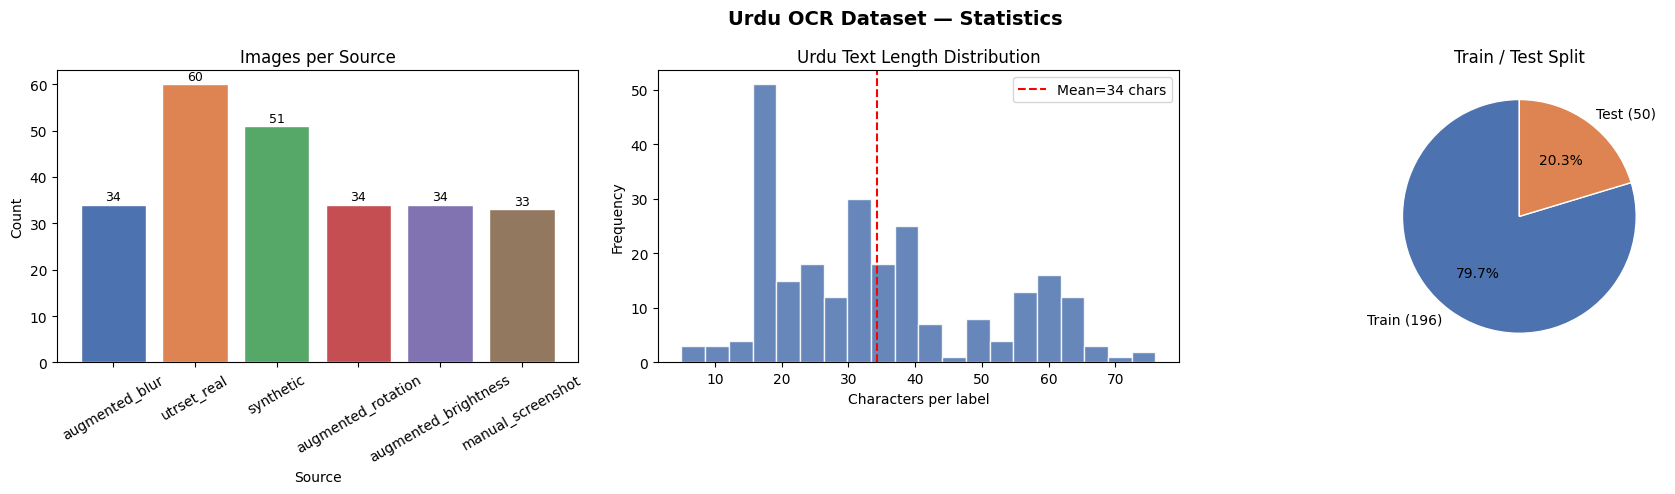

Plot saved: data/dataset_stats.png


In [35]:
def plot_dataset_stats(rows):
    """Generate three visualization plots for the dataset."""

    # ── 1. Count per source ──────────────────────────────────────────────────
    source_counts = {}
    for r in rows:
        src = r.get('source', 'unknown')
        source_counts[src] = source_counts.get(src, 0) + 1

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle("Urdu OCR Dataset — Statistics", fontsize=14, fontweight='bold')

    # Bar chart
    ax = axes[0]
    sources = list(source_counts.keys())
    counts  = [source_counts[s] for s in sources]
    colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2', '#937860']
    bars    = ax.bar(sources, counts, color=colors[:len(sources)], edgecolor='white')
    ax.set_title("Images per Source")
    ax.set_xlabel("Source")
    ax.set_ylabel("Count")
    ax.tick_params(axis='x', rotation=30)
    for bar, cnt in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                str(cnt), ha='center', va='bottom', fontsize=9)

    # ── 2. Text length histogram ────────────────────────────────────────────
    ax = axes[1]
    lengths = [len(r['text']) for r in rows if r.get('text')]
    ax.hist(lengths, bins=20, color='#4C72B0', edgecolor='white', alpha=0.85)
    ax.axvline(sum(lengths)/len(lengths), color='red', linestyle='--',
               linewidth=1.5, label=f"Mean={sum(lengths)//len(lengths)} chars")
    ax.set_title("Urdu Text Length Distribution")
    ax.set_xlabel("Characters per label")
    ax.set_ylabel("Frequency")
    ax.legend()

    # ── 3. Train / test split pie ───────────────────────────────────────────
    ax = axes[2]
    split_counts = {'train': 0, 'test': 0}
    for r in rows:
        if r.get('split') in split_counts:
            split_counts[r['split']] += 1
    ax.pie(
        split_counts.values(),
        labels=[f"Train ({split_counts['train']})", f"Test ({split_counts['test']})"],
        colors=['#4C72B0', '#DD8452'],
        autopct='%1.1f%%',
        startangle=90,
        wedgeprops={'edgecolor': 'white'}
    )
    ax.set_title("Train / Test Split")

    plt.tight_layout()
    plt.savefig("data/dataset_stats.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("Plot saved: data/dataset_stats.png")

plot_dataset_stats(valid_rows)


/tmp/ipykernel_2925/34503964.py:26: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2925/34503964.py:26: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.tight_layout()
/tmp/ipykernel_2925/34503964.py:26: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2925/34503964.py:27: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  plt.savefig("data/sample_grid.png", dpi=120, bbox_inches='tight')
/tmp/ipykernel_2925/34503964.py:27: UserWarning: Matplotlib currently does not support Arabic natively.
  plt.savefig("data/sample_grid.png", dpi=120, bbox_inches='tight')
/tmp/ipykernel_2925/34503964.py:27: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  plt.savefig("data/sample_grid.png", dpi=120, bbox_inches='tight')
/usr/local/lib/python3.12/dis

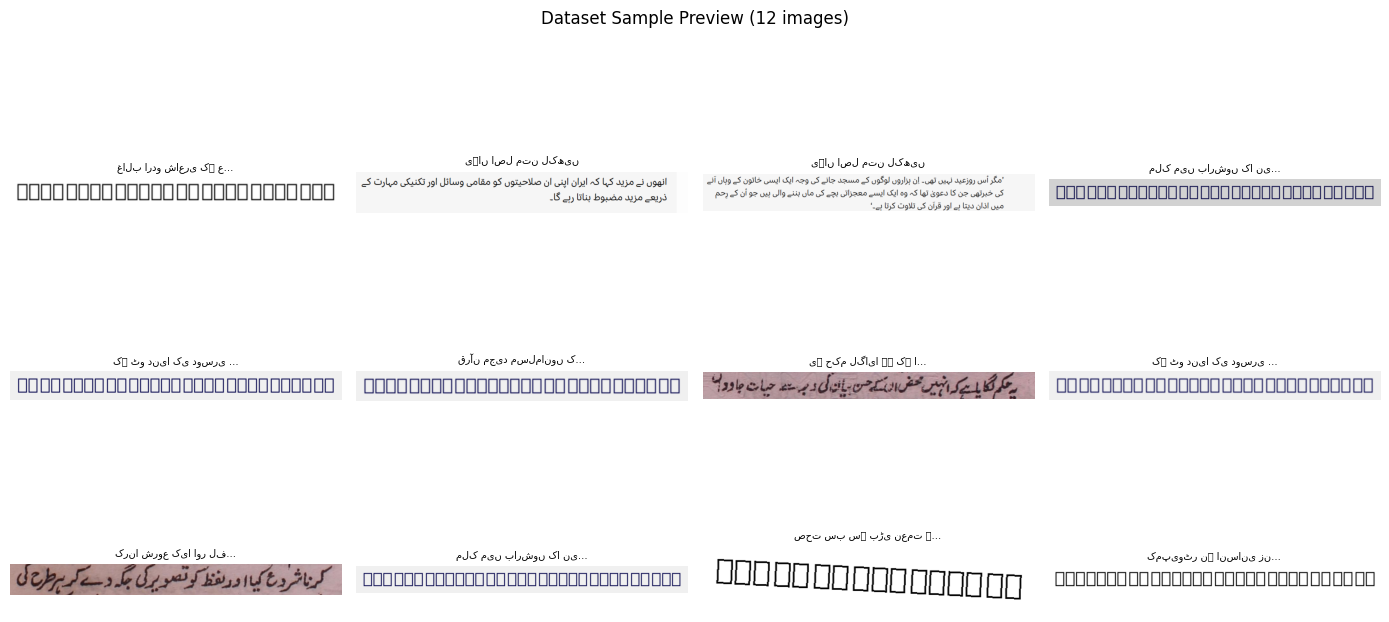

Grid saved: data/sample_grid.png


In [36]:

def plot_sample_grid(rows, n=12):
    """Show a grid of n randomly sampled images from the dataset."""
    sample = random.sample([r for r in rows if is_valid_image(r['image'])],
                           min(n, len(rows)))

    cols = 4
    rows_count = (len(sample) + cols - 1) // cols
    fig, axes = plt.subplots(rows_count, cols,
                             figsize=(cols * 3.5, rows_count * 2.5))
    axes = axes.flatten()

    for i, row in enumerate(sample):
        img = Image.open(row['image'])
        axes[i].imshow(img, cmap='gray' if img.mode == 'L' else None)
        axes[i].set_title(
            row['text'][:20] + ('…' if len(row['text']) > 20 else ''),
            fontsize=7
        )
        axes[i].axis('off')

    # Hide any unused subplot slots
    for j in range(len(sample), len(axes)):
        axes[j].axis('off')

    fig.suptitle(f"Dataset Sample Preview ({len(sample)} images)", fontsize=12)
    plt.tight_layout()
    plt.savefig("data/sample_grid.png", dpi=120, bbox_inches='tight')
    plt.show()
    print("Grid saved: data/sample_grid.png")

plot_sample_grid(valid_rows, n=12)


## 10. Final Summary

In [37]:
# ── Print a clean final summary of the entire dataset ───────────────────
with open(LABELS_CSV, 'r', encoding='utf-8') as f:
    all_final = list(csv.DictReader(f))

with open(TRAIN_CSV, 'r', encoding='utf-8') as f:
    train_final = list(csv.DictReader(f))

with open(TEST_CSV, 'r', encoding='utf-8') as f:
    test_final = list(csv.DictReader(f))

source_summary = {}
for r in all_final:
    src = r.get('source', 'unknown')
    source_summary[src] = source_summary.get(src, 0) + 1

print("=" * 50)
print("  URDU OCR DATASET — FINAL SUMMARY")
print("=" * 50)
print(f"  Total labeled images : {len(all_final)}")
print(f"  Training set         : {len(train_final)}")
print(f"  Test set             : {len(test_final)}")
print()
print("  Breakdown by source:")
for src, cnt in source_summary.items():
    print(f"    {src:<25} {cnt}")
print()
print("  Output files:")
print(f"    {LABELS_CSV}")
print(f"    {TRAIN_CSV}")
print(f"    {TEST_CSV}")
print(f"    data/dataset_stats.png")
print(f"    data/sample_grid.png")
print("=" * 50)


  URDU OCR DATASET — FINAL SUMMARY
  Total labeled images : 246
  Training set         : 196
  Test set             : 50

  Breakdown by source:
    utrset_real               60
    augmented_rotation        34
    augmented_blur            34
    manual_screenshot         33
    augmented_brightness      34
    synthetic                 51

  Output files:
    data/labels.csv
    data/train.csv
    data/test.csv
    data/dataset_stats.png
    data/sample_grid.png
